In [21]:
import warnings
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
from sklearn import tree
#import other needed libraries as well
from sklearn.model_selection import train_test_split 
warnings.filterwarnings('ignore')

In [22]:
df = pd.read_csv('adult.csv')
df.replace(' ?', pd.NA, inplace=True)
df.dropna(inplace=True)

exclusive_test = df.tail(20)
df = df.iloc[:-20]

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32541 entries, 0 to 32540
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32541 non-null  int64 
 1   workclass       32541 non-null  object
 2   fnlwgt          32541 non-null  int64 
 3   education       32541 non-null  object
 4   education-num   32541 non-null  int64 
 5   marital-status  32541 non-null  object
 6   occupation      32541 non-null  object
 7   relationship    32541 non-null  object
 8   race            32541 non-null  object
 9   sex             32541 non-null  object
 10  capital-gain    32541 non-null  int64 
 11  capital-loss    32541 non-null  int64 
 12  hours-per-week  32541 non-null  int64 
 13  native-country  32541 non-null  object
 14  income          32541 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [24]:
df.head(10)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


In [25]:
# Encode categorical columns to use all features
le = LabelEncoder()
categorical_columns = df.select_dtypes(include=['object']).columns

for col in categorical_columns:

    
    le.fit(pd.concat([df[col], exclusive_test[col]]))
    df[col] = le.transform(df[col])
    exclusive_test[col] = le.transform(exclusive_test[col])

In [26]:
df['income'].value_counts()

income
0    24704
1     7837
Name: count, dtype: int64

In [27]:
# Add Features which can't be used(atleast 2 and atmost 4 features other than income)
nonusable_columns = ["income", "sex", "race", "relationship"]

X = df.drop(columns = nonusable_columns)
y = df['income']

#split train & test sets
X_train, X_test,y_train, y_test = train_test_split(X,y , 
                                   random_state=42,  
                                   test_size=0.2,  
                                   shuffle=True) 

In [28]:
#train the model
#train the model
clf = tree.DecisionTreeClassifier(criterion="entropy", max_depth = 7)

clf = clf.fit(X_train, y_train)

In [34]:
# evaluate the model
from sklearn.metrics import accuracy_score

y_hat = clf.predict(X_test)


y_true = list(y_test)
y_pred = list(y_hat)
accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.8511292057151636


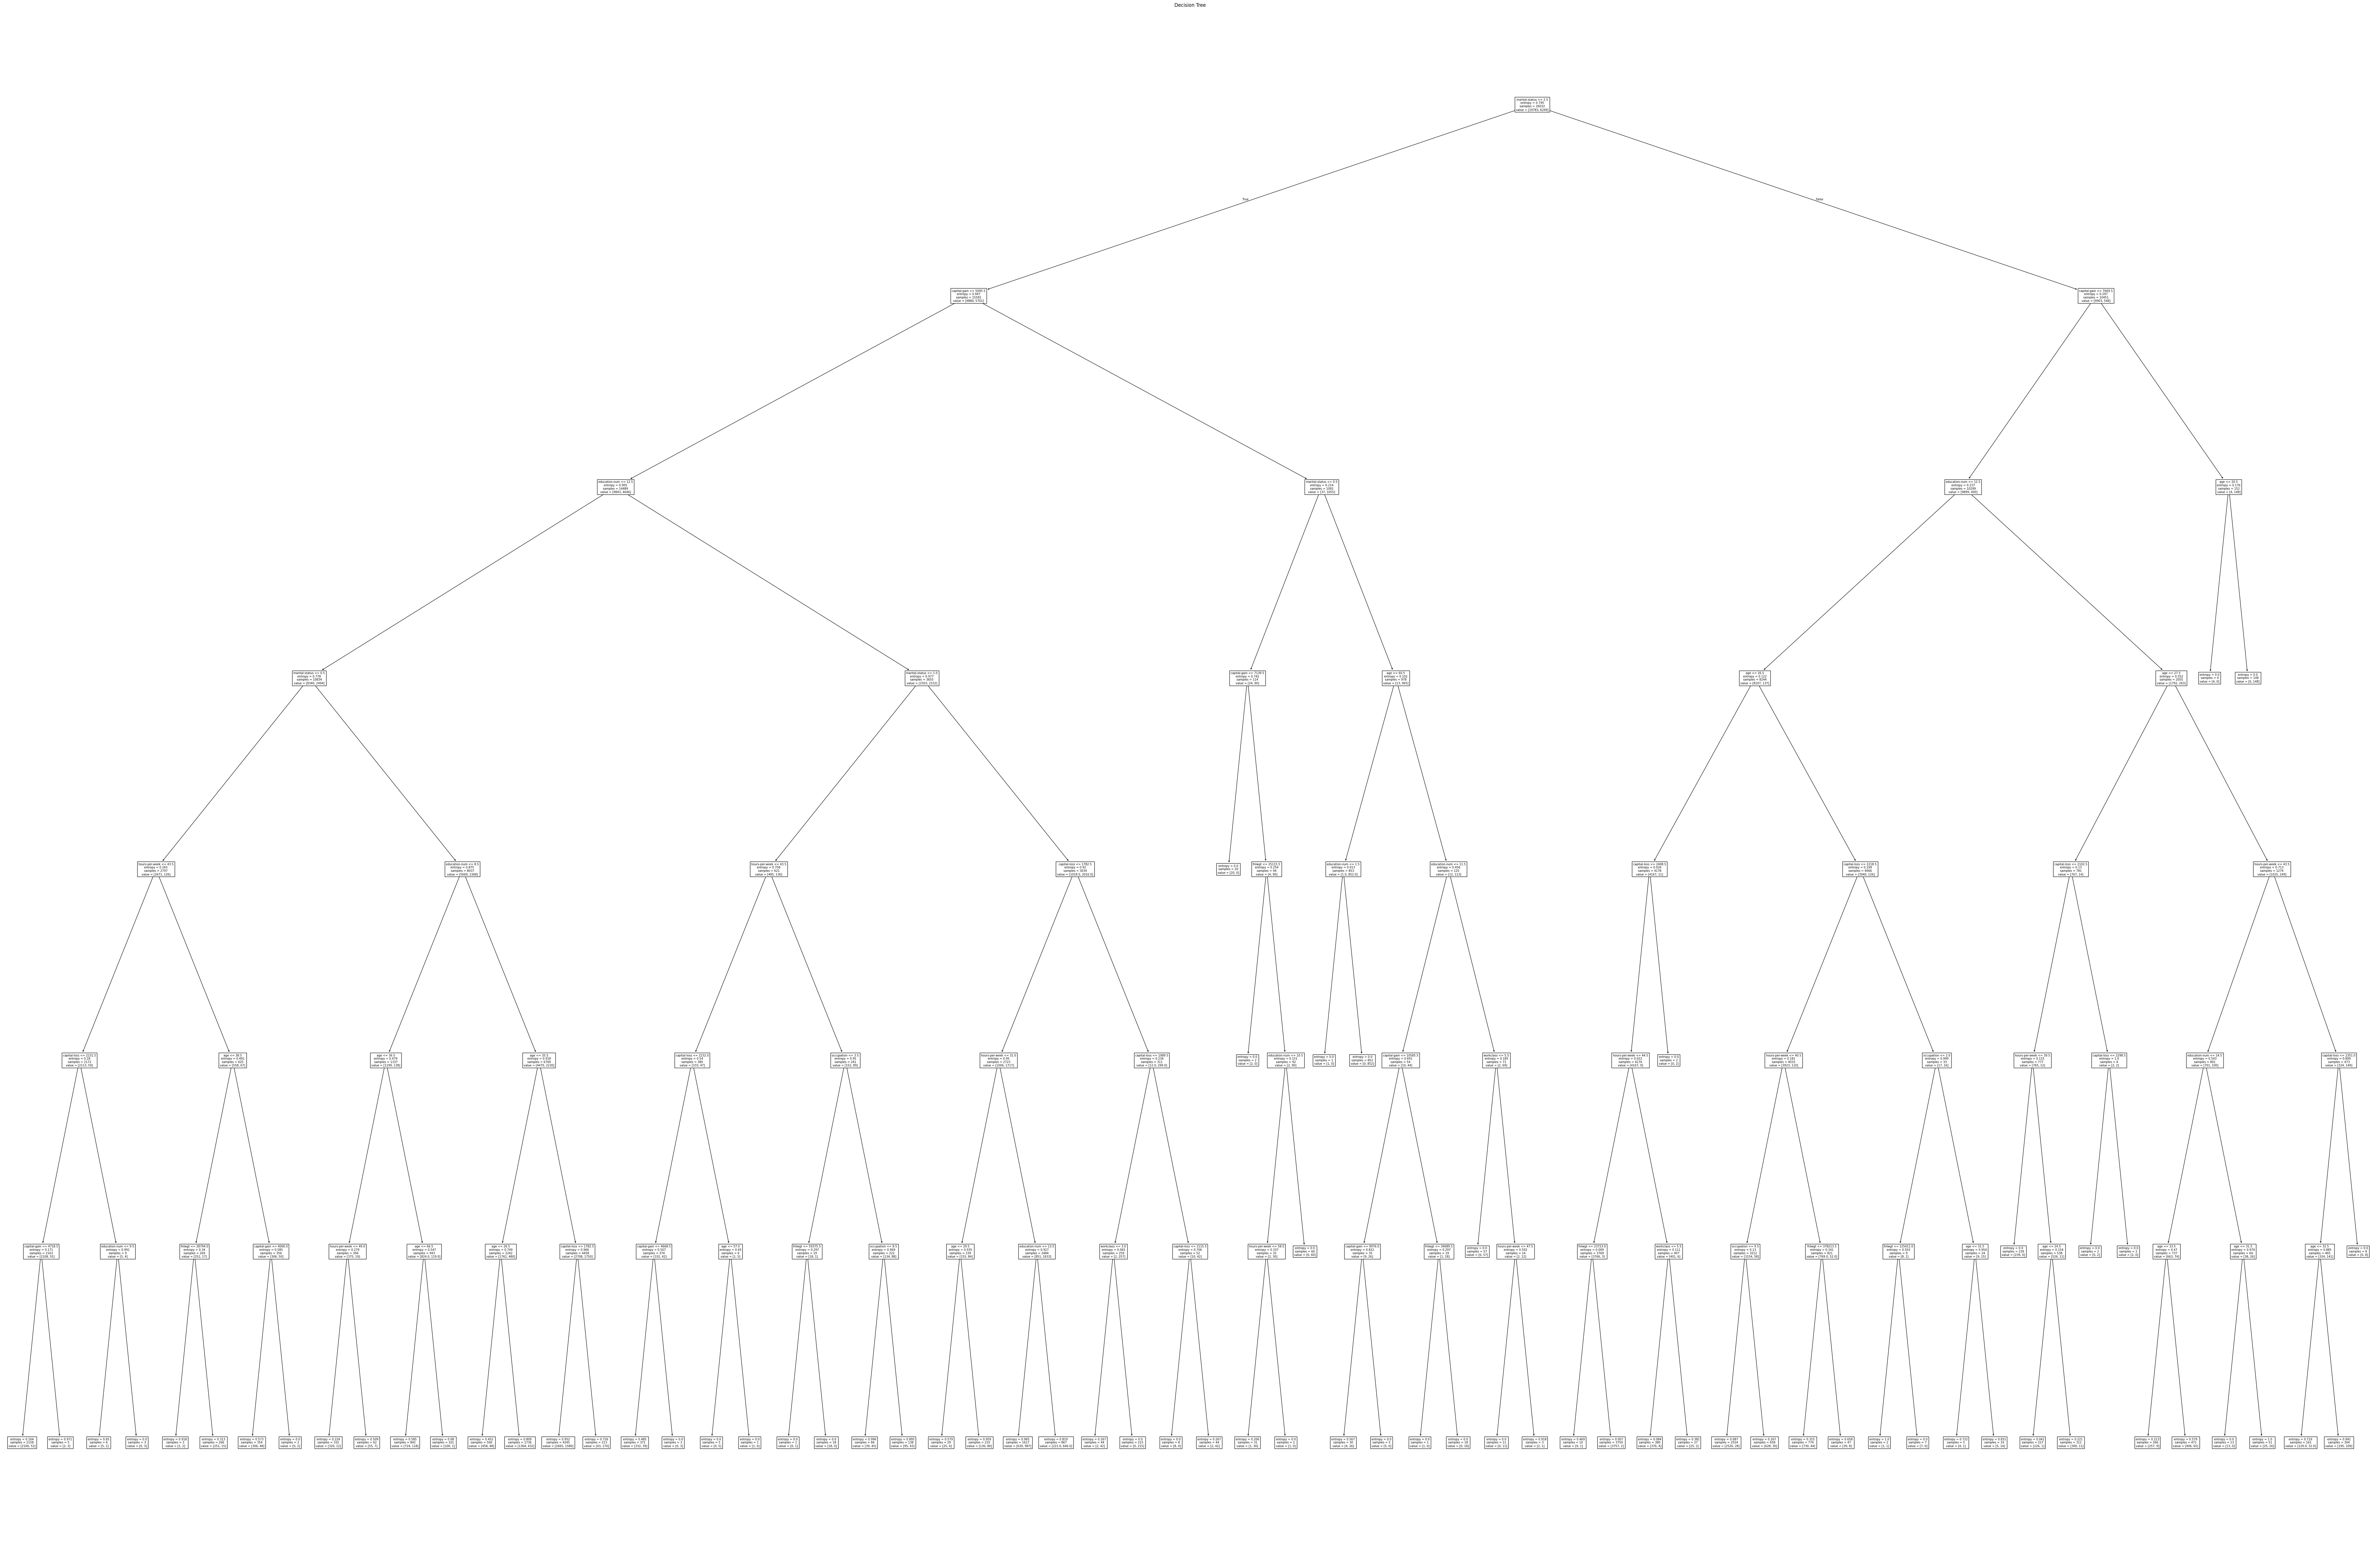

In [43]:
import matplotlib.pyplot as plt


plt.figure(figsize=(108, 70))
#plot your tree
tree.plot_tree(clf, max_depth=7, feature_names = X.columns.values)

plt.title("Decision Tree")
plt.show()

In [31]:
from IPython.display import display, HTML

display(HTML(exclusive_test.to_html()))

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
32541,41,0,202822,11,9,5,0,1,2,0,0,0,32,39,0
32542,72,0,129912,11,9,2,0,0,4,1,0,0,25,39,0
32543,45,2,119199,7,12,0,10,4,4,0,0,0,48,39,0
32544,31,4,199655,12,14,0,8,1,3,0,0,0,30,39,0
32545,39,2,111499,7,12,2,1,5,4,0,0,0,20,39,1
32546,37,4,198216,7,12,0,13,1,4,0,0,0,40,39,0
32547,43,4,260761,11,9,2,7,0,4,1,0,0,40,26,0
32548,65,6,99359,14,15,4,10,1,4,1,1086,0,60,39,0
32549,43,7,255835,15,10,0,1,2,4,0,0,0,40,39,0
32550,43,6,27242,15,10,2,3,0,4,1,0,0,50,39,0


In [32]:
X_finalTest = exclusive_test.drop(columns = nonusable_columns)
y_finalTest = exclusive_test['income']

num_wrong = 0
# add X_finalTest evaluation

predictions = clf.predict(X_finalTest)
print(len(predictions))

y_testing = list(y_finalTest)

for i in range(len(predictions)):
    if y_testing[i] != predictions[i]:
        num_wrong += 1
        


print(predictions)
print(y_finalTest.values)
print(f"Number of incorrect predictions in sample: {num_wrong}")

20
[0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]
[0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1]
Number of incorrect predictions in sample: 2


Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.95      0.91      4921
           1       0.79      0.54      0.64      1588

    accuracy                           0.85      6509
   macro avg       0.82      0.74      0.77      6509
weighted avg       0.85      0.85      0.84      6509



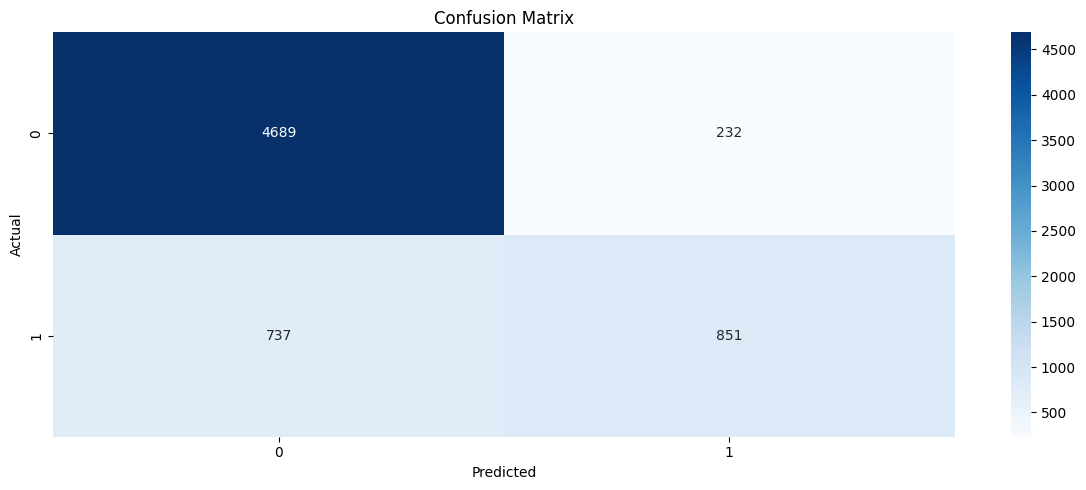

In [37]:

from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import classification_report

y_pred = clf.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))#F1,precision,recall
plt.figure(figsize=(12, 5))

# Confusion Matrix
plt.subplot(1, 1, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

# پنج عدد از مهمترین ویژگی هارا انتخاب کرده و رفتار درخت را با درخت قبلی مقایسه کنید. چرا این ویژگی ها بهترین ترکیب هستند؟

In [60]:
#put the best features in the below list e.g. ['a', 'b', 'c', ...]

columns_to_keep = [
    "income", "marital-status", "capital-gain", "education-num", "age", "capital-loss"
]

filtered_df = df[columns_to_keep]

In [61]:
X = filtered_df.drop('income', axis=1)
y = filtered_df['income']

# split your train & test set and train the model again


#split train & test sets
X_train2, X_test2,y_train2, y_test2 = train_test_split(X,y , 
                                   random_state=42,  
                                   test_size=0.2,  
                                   shuffle=True) 
#train the model
clf2 = tree.DecisionTreeClassifier(criterion="entropy", max_depth = 7)

clf2 = clf2.fit(X_train2, y_train2)


In [62]:
#evaluate the model
from sklearn.metrics import accuracy_score

y_hat2 = clf2.predict(X_test2)


y_true2 = list(y_test2)
y_pred2 = list(y_hat2)
accuracy2 = accuracy_score(y_true2, y_pred2)
print(f"Accuracy: {accuracy2}")

Accuracy: 0.8509755722845291


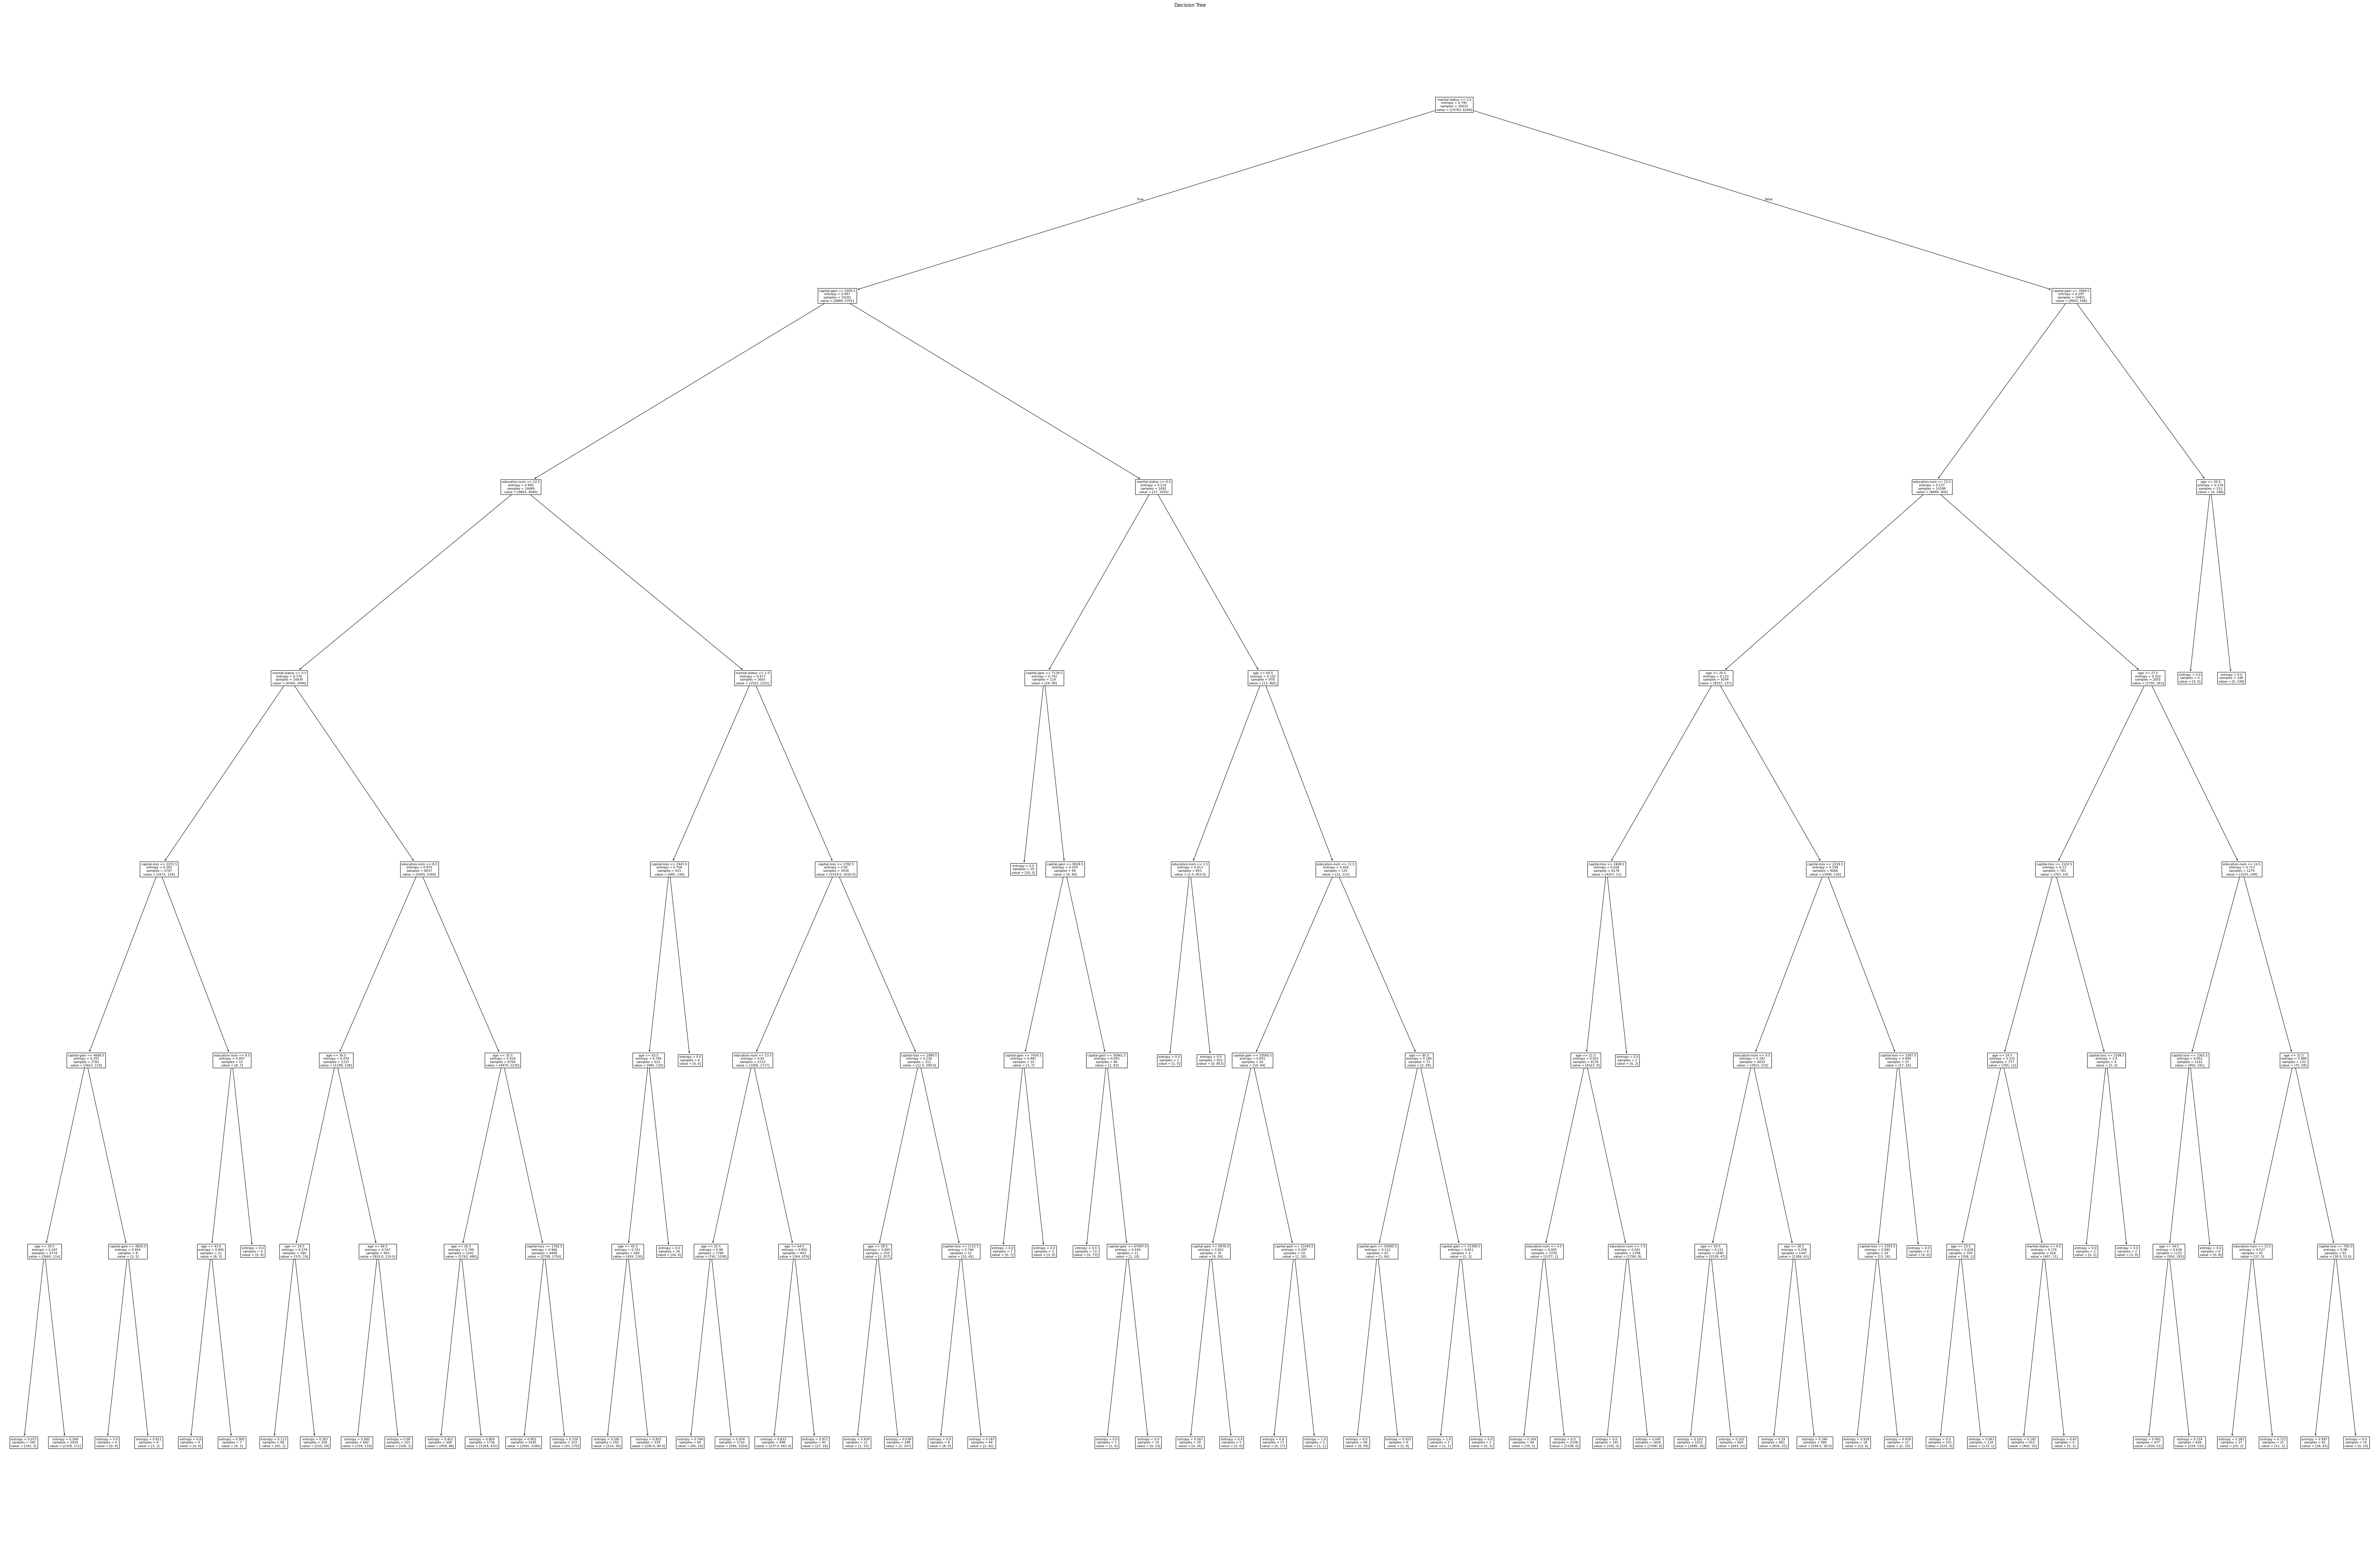

In [63]:
plt.figure(figsize=(108, 70))
# plot the final tree

#plot your tree
tree.plot_tree(clf2, max_depth=7, feature_names = X.columns.values)

plt.title("Decision Tree")
plt.show()

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.95      0.91      4921
           1       0.78      0.54      0.64      1588

    accuracy                           0.85      6509
   macro avg       0.82      0.75      0.77      6509
weighted avg       0.84      0.85      0.84      6509



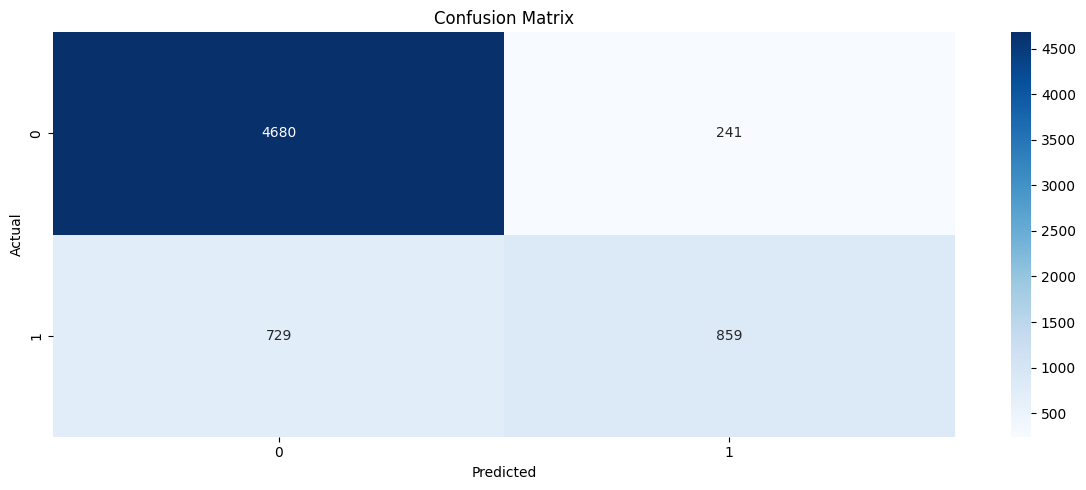

In [64]:

from sklearn.metrics import confusion_matrix
import seaborn as sns


y_pred2 = clf2.predict(X_test2)


print("Classification Report:")
print(classification_report(y_test2, y_pred2))#F1,Precision,Recall

plt.figure(figsize=(12, 5))

# Confusion Matrix
plt.subplot(1, 1, 1)
cm = confusion_matrix(y_test2, y_pred2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')



plt.tight_layout()
plt.show()

In [65]:

X_finalTest2 = exclusive_test[columns_to_keep].drop(columns = 'income')
y_finalTest2 = exclusive_test['income']

# add X_finalTest evaluation
num_wrong2 = 0
# add X_finalTest evaluation
predictions2 = clf2.predict(X_finalTest2)
print(len(predictions2))

y_testing2 = list(y_finalTest2)

for i in range(len(predictions2)):
    if y_testing2[i] != predictions2[i]:
        num_wrong2 += 1

print(predictions2)
print(y_finalTest2.values)
print(f"Number of incorrect predictions: {num_wrong2}")

20
[0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 1]
[0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1]
Number of incorrect predictions: 3
